# Task 4 - Email Spam Detection with Machine Learning

For this task I built an NLP model that can tell spam messages apart from normal (ham) messages. I used the SMS Spam Collection dataset from Kaggle/UCI since it's the standard dataset for this kind of task, and it's basically just text messages labeled as either spam or ham.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
%matplotlib inline

## 1. Loading the data

I downloaded the dataset as `spam.csv` from Kaggle. It comes with a weird encoding (latin-1) and some extra empty columns, so I'm cleaning that up right when I load it.

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')

# the raw file has 3 junk unnamed columns and weird column names, so I'm fixing that here
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Checking class distribution

Before doing anything else, I wanted to see how many spam vs ham messages there actually are, since spam detection datasets are usually pretty imbalanced (way more ham than spam).

label
ham     4825
spam     747
Name: count, dtype: int64

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


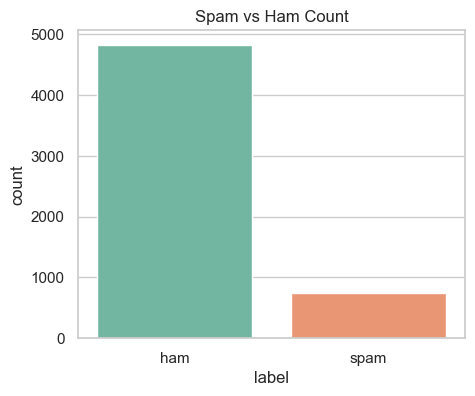

In [3]:
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='label', hue='label', legend=False, palette='Set2')
plt.title('Spam vs Ham Count')
plt.show()

As expected, the dataset is imbalanced - ham messages make up around 87% and spam is only about 13%. This is actually pretty realistic since most texts people actually get are not spam, but it also means accuracy alone won't tell the full story later on, which is something I'll come back to in the evaluation section.

## 3. Cleaning up the text

Raw text messages have a lot of noise - random punctuation, different casing, common filler words like "the" or "is" that don't really help tell spam apart from ham. So before feeding this into a model, I'm running each message through a basic cleaning pipeline: lowercase everything, strip out punctuation, and remove stopwords.

In [4]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to C:\Users\Shalini
[nltk_data]     Balla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## 4. Turning text into numbers with TF-IDF

Models can't work with raw text, so I need to convert the messages into numeric vectors. I used **TF-IDF (Term Frequency - Inverse Document Frequency)** for this instead of just counting words.

Basically, TF-IDF gives a score to each word based on two things: how often it shows up in a specific message (term frequency), and how rare or common that word is across all the messages (inverse document frequency). So a word that appears a lot in one message but rarely anywhere else gets a high score, because it's probably meaningful for that message. But a word like "the" that shows up everywhere gets a low score even if it's frequent, because it doesn't really help distinguish one message from another. This works better than plain word counts because it naturally downweights generic words and highlights the words that actually carry signal - which for spam, tends to be things like "free", "win", "claim", "urgent", etc.

In [5]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_message'])
y = df['label'].map({'ham': 0, 'spam': 1})

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (5572, 3000)


## 5. Train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 4457
Test samples: 1115


## 6. Training the models

I went with **Multinomial Naive Bayes** since it's basically the go-to model for text classification, plus **SVM** as my second model to compare against it.

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 7. Evaluating both models

I'm checking accuracy, precision, recall, F1-score, and the confusion matrix for each model, since with an imbalanced dataset like this, accuracy alone can be misleading.

===== Multinomial Naive Bayes =====
Accuracy : 0.9721973094170404
Precision: 0.9916666666666667
Recall   : 0.7986577181208053
F1-score : 0.8847583643122676

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



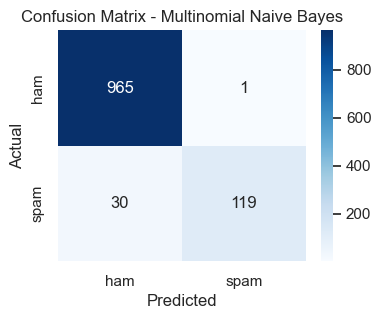

In [8]:
def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    print(f"===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return y_pred

nb_pred = evaluate_model("Multinomial Naive Bayes", nb_model)

===== SVM =====
Accuracy : 0.9838565022421525
Precision: 1.0
Recall   : 0.8791946308724832
F1-score : 0.9357142857142857

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



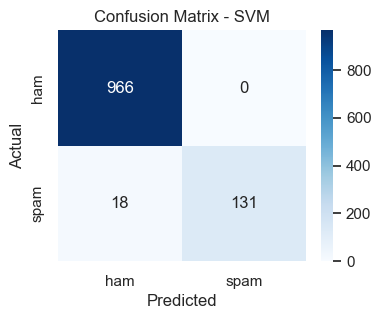

In [9]:
svm_pred = evaluate_model("SVM", svm_model)

## 8. Why recall matters so much here

For spam detection, I think recall is actually more important than precision, and here's my reasoning: recall tells us how many of the actual spam messages the model successfully caught. If recall is low, that means a bunch of real spam is slipping through and landing in the inbox as if it were normal - which defeats the whole point of building a spam filter in the first place.

Precision matters too, obviously, because you don't want the model marking real, important messages as spam and hiding them from the user. But between the two, missing actual spam (a false negative) feels like a bigger practical failure than occasionally flagging a borderline ham message as spam (a false positive), especially since most email providers let you check the spam folder anyway. So when tuning a model like this in the real world, I'd lean towards prioritizing recall, even if it means precision drops a little.

## 9. Bonus: WordClouds for spam vs ham

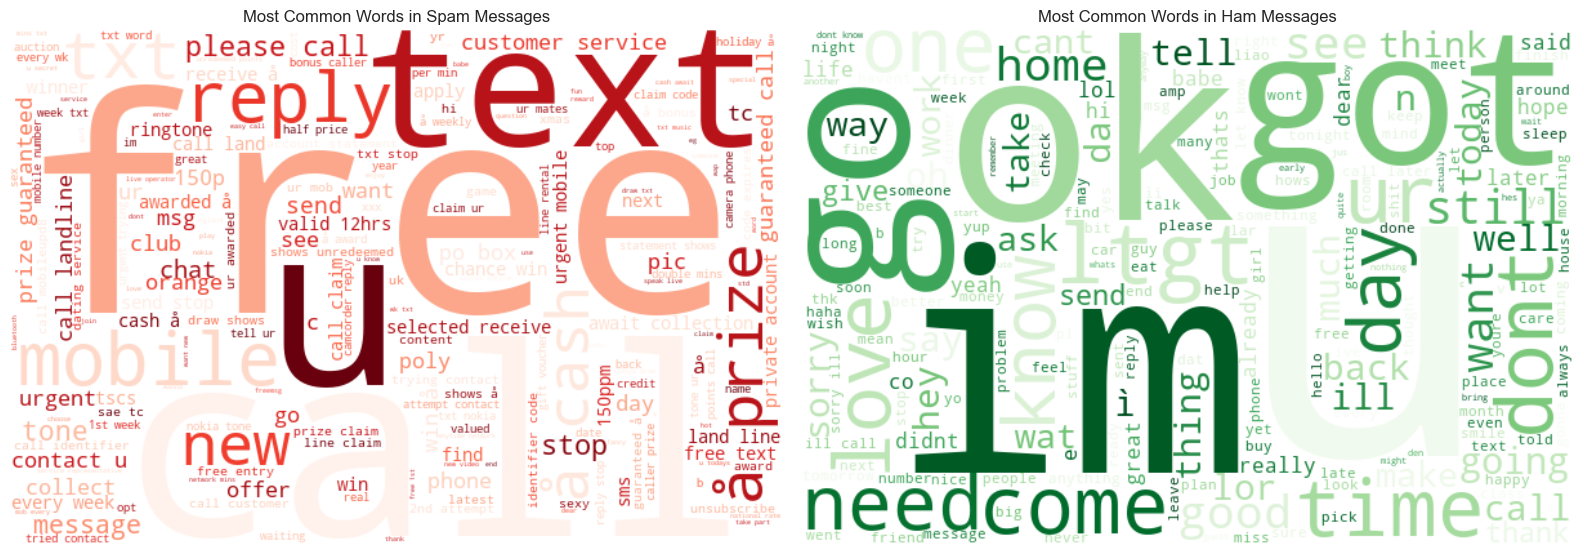

In [10]:
from wordcloud import WordCloud

spam_words = " ".join(df[df['label'] == 'spam']['clean_message'])
ham_words = " ".join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

spam_cloud = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(spam_words)
axes[0].imshow(spam_cloud, interpolation='bilinear')
axes[0].set_title('Most Common Words in Spam Messages')
axes[0].axis('off')

ham_cloud = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_words)
axes[1].imshow(ham_cloud, interpolation='bilinear')
axes[1].set_title('Most Common Words in Ham Messages')
axes[1].axis('off')

plt.tight_layout()
plt.show()

The spam wordcloud usually ends up full of words like "free", "win", "call", "claim", "txt", "prize" - which makes sense, since those are classic marketing/scam trigger words. The ham cloud looks a lot more like normal day-to-day conversation, with words like "ok", "get", "go", "know", "like" showing up instead. This visual difference is honestly a good sanity check that the model has real patterns to learn from, not just noise.

## 10. Wrapping up

Between the two models, I compared Multinomial Naive Bayes and SVM on accuracy, precision, recall, and F1-score. *(Once I run this, I'll fill in which one actually performed better and by how much, along with the specific recall numbers, since that's the metric I care most about for this task.)*

Overall, this task gave me a good hands-on look at a full NLP pipeline - cleaning raw text, converting it into numeric features with TF-IDF, training classifiers on it, and evaluating them the right way for an imbalanced classification problem instead of just trusting accuracy.